# ZITboost 실험 — ZI-Tweedie + LightGBM EM
## 3차 funnel: Two-Stage 대안 (분류 실패 우회)

**배경**: 1차 실험 5,750 trial 분석 결과, Stage 1 분류 성능이 Recall 평균 0.011, AUC 0.576으로 거의 랜덤 수준.  
분류 실패로 Two-Stage의 `P(Y>0) × E[Y|Y>0]` 곱셈이 예측을 0으로 수렴시키는 구조적 문제 발생.  
ZITboost는 π(zero 확률) + μ(Tweedie mean) + φ(dispersion)를 EM으로 동시 학습하여 분류 실패를 우회한다.

**핵심 차이**:
- `run_clf=False` — ZITboost 내부 π가 분류 역할
- `reg_models=['zitboost']` — 단일 모델
- `TARGET_TRANSFORM='none'` — Tweedie가 분포 처리
- 후처리: 집계 함수 탐색, π threshold tuning, zero_clip

In [1]:
import os, sys

try:
    import google.colab
    if not os.path.exists("/content/project/setup.py"):
        os.system("pip install -q gdown")
        os.system("gdown --id 1AD4PDBnDVjp-LSna6puB7qLnpBqB7j_I -O /content/code.zip")
        os.system("unzip -qo /content/code.zip -d /content/project")
        os.makedirs("/content/project/0_data", exist_ok=True)
        os.system("gdown --id 1yOUo0_wPLcuZBSJIK592b00YkSIlk4zO -O /content/project/0_data/dataset.zip")
        os.system("unzip -qo /content/project/0_data/dataset.zip -d /content/project/0_data")
        os.remove("/content/project/0_data/dataset.zip")
    # modules.zip
    if not os.path.exists("/content/project/3_modeling/modules/e2e_hpo.py"):
        os.system("gdown --id ... -O /content/project/3_modeling/modules.zip")  # TODO: modules zip ID
        os.system("unzip -qo /content/project/3_modeling/modules.zip -d /content/project/3_modeling/modules")
    sys.path.insert(0, "/content/project")
    sys.path.insert(0, "/content/project/3_modeling")
    %run /content/project/setup.py
except ImportError:
    sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd())))
    %run ../../setup.py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import warnings
warnings.filterwarnings('ignore')

from utils.config import (PROJECT_ROOT, SEED, TARGET_COL, KEY_COL,
                           POSITION_COL, OUTPUT_DIR)
from utils.data import load_all, get_feat_cols, split_xs
from utils.evaluate import rmse

from modules.e2e_hpo import (run_e2e_optimization_with_pp,
                              rerun_best_trial_with_pp)
from modules.zi_tweedie import ZITboostRegressor
from modules.search_space import SEARCH_SPACES

print(f"ZITboost registered: {'zitboost' in SEARCH_SPACES}")
print(f"PROJECT_ROOT: {PROJECT_ROOT}")

setup 완료
ZITboost registered: True
PROJECT_ROOT: c:\Users\Dell5371\Desktop\기업연계프로젝트


## 2. 실험 설정

모든 스위치를 한 곳에 모아 관리. 테스트/본실험 전환은 주석 참고.

In [ ]:
# ============================================================
# 실험 설정 (ZITboost — ZI-Tweedie + LightGBM EM)
# ============================================================
#
# ★★★ 실험 전 체크리스트 — 아래 항목을 반드시 확인/수정 후 실행 ★★★
# ┌─────────────────────────────────────────────────────────┐
# │  1. EXP_ID      — 실험 고유 ID (중복 금지)                    │
# │  2. n_trials    — Optuna trial 수 (테스트=10, 본실험=50~100)  │
# │  3. n_folds     — CV fold 수 (테스트=3, 본실험=5)             │
# │  4. use_sampling — 샘플링 (테스트=True/0.1, 본실험=False)      │
# │  5. EVAL_TEST   — test 평가 (peek 위험, 최종 제출 전만 True)   │
# │  6. DEVICE      — 'cpu' 또는 'gpu' (벤치마크 후 선택)          │
# └─────────────────────────────────────────────────────────┘

# ── 실험 식별 (매 실험마다 수정) ──
EXP_ID = 'zit-001'              # ★ 수정 필수: 실험 고유 ID
EXP_MEMO = 'ZI-Tweedie + LightGBM EM, position pivot'
                                # ★ 수정 필수: 이번 실험 변경사항 메모
USER = 'jh'                     # ★ 수정 필수: 본인 이니셜 ('jh', 'jw' 등)

# ── LightGBM Device ──
DEVICE = 'cpu'                  # ★ 'cpu' = 14코어 병렬 | 'gpu' = T600 등 GPU 가속

# 모듈 내부 DEVICE 오버라이드 (py 파일 수정 없이 노트북에서만 적용)
import modules.model_zoo as _mz
import modules.search_space as _ss
_mz.DEVICE = DEVICE
_ss.DEVICE = DEVICE
print(f"DEVICE override: {DEVICE}")

# ── 평가·저장 ──
EVAL_VAL  = True                # val RMSE 계산 (항상 True 권장)
EVAL_TEST = True                # ★ test RMSE 계산 (peek 위험 — 최종 제출 직전만 True 권장)
SAVE_OUTPUTS = True             # True→CSV, JSON, DB 저장 | False→in-memory만

# ── 타깃 ──
TARGET_TRANSFORM = 'none'       # 고정: Tweedie가 분포 직접 처리 → 외부 변환 불필요
CLIP_Y_EXTREME = True           # train max(1.0) → second_max로 클립

# ── 웨이퍼맵 사전 제외 (Stage 0, 35개) ──
# 출처: 1_eda/wafer_map_image/★분류완료/1_꼭빼야함/ 수동 분류
EXCLUDE_COLS = [
    'X124', 'X300', 'X301',
    'X443', 'X444', 'X447', 'X448', 'X449',
    'X451', 'X452', 'X455', 'X456', 'X457', 'X458', 'X459', 'X460',
    'X463', 'X464',
    'X503', 'X504', 'X505', 'X506',
    'X517',
    'X658', 'X659', 'X671', 'X672',
    'X674', 'X675', 'X676', 'X677',
    'X680', 'X687',
    'X1074', 'X1078',
]

# ── Pipeline (ZITboost 고정값 — 수정 불필요) ──
# ZITboost는 내부 π가 분류 담당 → 외부 clf/FS 전부 비활성
pipeline_config = dict(
    input_level='die',          # 고정: die-level 입력
    run_clf=False,              # 고정: ZITboost 내부 π가 분류 역할
    clf_filter=False,           # 고정: 외부 clf 없으므로 필터링 불가
    clf_optuna=False,           # 고정: 외부 clf 없음
    run_fs=False,               # 고정: FS 비활성 (3차에서 검토)
    fs_optuna=False,            # 고정: FS 비활성
    reg_level='position',       # 'position'=die 4개를 position별 피벗 | 'unit'=집계 통계
    reg_optuna=True,            # True→ZITboost 21개 HP를 Optuna 탐색
    zero_clip=False,            # 고정: 후처리 셀(Cell 10)에서 별도 grid search
)

# ── E2E HPO (★ 규모 조절) ──
e2e_params = dict(
    reg_models=['zitboost'],    # 고정: ZITboost 단일 모델
    n_trials=2,
    n_folds=3,                  # ★ 테스트=3, 본실험=5
)

# ── Rerun (best trial 재학습) ──
rerun_params = dict(
    mode='kfold',               # 'kfold'=K-fold OOF 생성 | 'single'=단일 학습
    n_folds=5,                  # ★ 테스트=3, 본실험=5
)

# ── 후처리 (Cell 8~10에서 사용) ──
postprocess_config = dict(
    # --- Cell 8: 집계 함수 (die 4개 예측 → unit 1개로 합치는 방법) ---
    agg_method='mean',          # ★ 'auto'=6종 전체 탐색 후 best 선택 | 'mean' 등=고정
                                # 고정: 'mean'/'weighted'/'max'/'min'/'median'/'trimmed_mean'
    agg_candidates=['mean', 'weighted', 'max', 'min', 'median', 'trimmed_mean'],
    position_weight_range=(0.15, 0.35),  # weighted 선택 시 SLSQP w1~w4 범위 (균등=0.25)

    # --- Cell 9: π threshold (예측값 하위 분위수를 0으로 강제) ---
    pi_threshold=None,          # ★ 'auto'=grid search | float=고정값 | None=비활성
    pi_threshold_range=(0.0, 0.95),   # ★ 탐색 분위수 범위 (0.0부터 시작 → 안 자르는 경우도 탐색)
    pi_threshold_step=0.01,           # 탐색 해상도

    # --- Cell 10: zero_clip (작은 예측값을 0으로 강제) ---
    zero_clip_threshold=None,   # ★ 'auto'=train OOF 기반 grid search | float=고정 | None=비활성
    zero_clip_range=(0.0, 0.002),     # 탐색 범위
    zero_clip_step=0.0005,            # 탐색 해상도
)

# ── 샘플링 (테스트/디버깅용) ──
sampling_params = dict(
    use_sampling=True,         # ★ 본실험=False(전체), 테스트=True
    sample_frac=0.05,            #    True일 때만 적용 (0.1=10%, 0.2=20%)
)

# ── Warm-start (기존 DB trial 재활용) ──
# DB가 비어있는 첫 실행에선 영향 없음. 재개 시에만 상위 K trial 재활용.
warm_start = dict(
    warm_start_enabled=False,   # True→기존 DB에서 상위 trial 재활용 | False→새로 탐색
    warm_start_top_k=10,        # 재활용할 상위 trial 수
)

# ── 경로 (자동 생성) ──
OOF_DIR = os.path.join(OUTPUT_DIR, 'oof', EXP_ID)
os.makedirs(OOF_DIR, exist_ok=True)
DB_PATH = os.path.join(OOF_DIR, f'{EXP_ID}.db')

# ── 설정 출력 ──
print(f"EXP_ID: {EXP_ID} | {EXP_MEMO}")
print(f"USER: {USER}")
print(f"DEVICE: {DEVICE}")
print(f"Trials: {e2e_params['n_trials']} | Folds: main={e2e_params['n_folds']}, rerun={rerun_params['n_folds']}")
print(f"Sampling: {'ON ('+str(sampling_params['sample_frac'])+')' if sampling_params['use_sampling'] else 'OFF'}")
print(f"타깃: {TARGET_TRANSFORM} | CLIP: {CLIP_Y_EXTREME}")
print(f"OOF_DIR: {OOF_DIR}")

## 3. 전처리 Search Space

1차 실험 best 전처리로 축소. 필요 시 후보를 추가/제거하여 조정.

In [3]:
from modules.search_space import (
    PP_CLEAN_CANDIDATES, PP_OUTLIER_CANDIDATES,
    # PP_ISO_ANOMALY_CANDIDATES, PP_LDS_CANDIDATES,  # ★ 비활성 (baseline 동일 조건)
    PP_BINARIZE_CONFIG,                               # ★ Binarize 비활성용
    AGG_PRESETS, PP_AGG_PRESET_IDX_CANDIDATES,
)

# ── 추가 전처리 비활성화 (baseline 동일 조건) ──
PP_BINARIZE_CONFIG["apply"] = False                    # ★ Binarize OFF
PP_ISO_ANOMALY_CANDIDATES = {"iso_enabled": [False]}   # ★ IsoForest OFF
PP_LDS_CANDIDATES = {"lds_enabled": [False]}           # ★ LDS OFF

# ── 1차 best 전처리로 축소 (필요 시 수정) ──
PP_CLEAN_CANDIDATES['imputation_method'] = ['spatial']
PP_OUTLIER_CANDIDATES['method'] = ['winsorize']

# 확인
print("=== 전처리 Search Space ===")
for name, cands in [
    ("Clean", PP_CLEAN_CANDIDATES),
    ("Outlier", PP_OUTLIER_CANDIDATES),
    # ("IsoForest", PP_ISO_ANOMALY_CANDIDATES),  # 비활성
    # ("LDS", PP_LDS_CANDIDATES),                # 비활성
]:
    print(f"\n[{name}]")
    for k, v in cands.items():
        print(f"  {k}: {v}")
print(f"\n[비활성] Binarize apply={PP_BINARIZE_CONFIG['apply']}, "
      f"IsoForest={PP_ISO_ANOMALY_CANDIDATES}, LDS={PP_LDS_CANDIDATES}")
print(f"\nAGG_PRESETS ({len(AGG_PRESETS)}개): {AGG_PRESETS}")

=== 전처리 Search Space ===

[Clean]
  const_threshold: [1e-06]
  missing_threshold: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
  remove_duplicates: [True]
  corr_threshold: [0.9, 0.94, 0.98]
  corr_keep_by: ['std', 'target_corr']
  add_indicator: [True, False]
  indicator_threshold: [0.01, 0.05, 0.1, 0.15, 0.2, 0.25]
  imputation_method: ['spatial']
  knn_neighbors: [3, 5, 10]
  spatial_max_dist: [1.0, 2.0, 3.0, 4.0, 5.0]
  post_impute_corr_threshold: [0.97, 0.98, 0.99]
  post_impute_corr_keep_by: ['std', 'target_corr']

[Outlier]
  method: ['winsorize']
  lower_pct: [0.0]
  upper_pct: [0.99]
  iqr_multiplier: [1.5, 3.0, 5.0]

[비활성] Binarize apply=False, IsoForest={'iso_enabled': [False]}, LDS={'lds_enabled': [False]}

AGG_PRESETS (4개): [['mean', 'std', 'range', 'min', 'max', 'median'], ['mean', 'std'], ['mean', 'std', 'median', 'range'], ['std', 'range', 'median']]


## 4. 데이터 로드 + 타겟 변환

- Stage 0: 웨이퍼맵 사전 제외 (35개)
- 타겟 변환: `none` 고정 (Tweedie가 분포 직접 처리)
- 극단값 클립: train max → second_max

In [4]:
# ── 데이터 로드 ──
xs, ys = load_all()
feat_cols = get_feat_cols(xs)
xs_dict = split_xs(xs)
print(f"xs: {xs.shape}, ys keys: {list(ys.keys())}")

# ── Stage 0: 웨이퍼맵 사전 제외 ──
xs = xs.drop(columns=[c for c in EXCLUDE_COLS if c in xs.columns])
feat_cols = get_feat_cols(xs)
xs_dict = split_xs(xs)
print(f"feat_cols after EXCLUDE: {len(feat_cols)}")

# ── 타겟 변환: none (고정) ──
target_transform_fn = None
target_inverse_fn = None

# ── 극단값 클립 ──
ys_input = {k: v.copy() for k, v in ys.items()}
if CLIP_Y_EXTREME:
    _train_y = ys_input['train'][TARGET_COL]
    _second_max = _train_y[_train_y < _train_y.max()].max()
    n_clipped = (_train_y > _second_max).sum()
    ys_input['train'][TARGET_COL] = _train_y.clip(upper=_second_max)
    print(f"CLIP_Y_EXTREME: {n_clipped}개 클립 (max {_train_y.max():.4f} → {_second_max:.4f})")

# ── 샘플링 (train만 축소, val/test는 풀 유지) ──
if sampling_params['use_sampling']:
    train_mask = xs['split'] == 'train'
    train_units = xs.loc[train_mask, KEY_COL].unique()
    sample_n = int(len(train_units) * sampling_params['sample_frac'])
    sample_units = np.random.RandomState(SEED).choice(
        train_units, size=sample_n, replace=False
    )
    # train 중 샘플된 unit + val/test 전체
    keep_mask = (~train_mask) | (xs[KEY_COL].isin(sample_units))
    xs = xs[keep_mask].reset_index(drop=True)
    xs_dict = split_xs(xs)
    # ys도 train만 축소
    ys_input['train'] = ys_input['train'][
        ys_input['train'][KEY_COL].isin(sample_units)
    ].reset_index(drop=True)
    print(f"Sampling: train {len(train_units)} → {sample_n} units "
          f"({sampling_params['sample_frac']*100:.0f}%), val/test 풀 유지")

[load_xs] all-NaN 행 407개 제거 → 174,573행
Xs: (174573, 1091)  |  Ys: train=26,247, val=8,749, test=8,749
xs: (174573, 1091), ys keys: ['train', 'validation', 'test', 'all']
feat_cols after EXCLUDE: 1052
CLIP_Y_EXTREME: 1개 클립 (max 1.0000 → 0.0974)
Sampling: train 26188 → 1309 units (5%), val/test 풀 유지


## 5. Optuna HPO

ZITboost 단일 모델 HPO. 탐색 축 21개 (μ 9 + π 5 + φ 5 + zeta + n_em_iters).

In [5]:
study_user_attrs = {
    'exp_id': EXP_ID,
    'exp_type': 'ZITboost HPO',
    'exp_memo': EXP_MEMO,
    'user': USER,
    'device': DEVICE,
    'pipeline_config': pipeline_config,
    'e2e_params': e2e_params,
    'rerun_params': rerun_params,
    'sampling_params': sampling_params,
    'postprocess_config': postprocess_config,
    'label_col': 'label_bin',
    'exclude_cols': EXCLUDE_COLS,
    'target_transform': TARGET_TRANSFORM,
    'clip_y_extreme': CLIP_Y_EXTREME,
    'warm_start': warm_start,
    'preprocessing_search_space': {
        'PP_CLEAN_CANDIDATES':   {k: list(v) for k, v in PP_CLEAN_CANDIDATES.items()},
        'PP_OUTLIER_CANDIDATES': {k: list(v) for k, v in PP_OUTLIER_CANDIDATES.items()},
        'AGG_PRESETS':           [list(p) for p in AGG_PRESETS],
    },
}

result = run_e2e_optimization_with_pp(
    xs=xs, xs_dict=xs_dict, ys=ys_input, feat_cols=feat_cols,
    pipeline_config=pipeline_config,
    label_col='label_bin',
    use_sampling=sampling_params['use_sampling'],
    sample_frac=sampling_params['sample_frac'],
    exclude_cols=EXCLUDE_COLS,
    # ── ZITboost ──
    reg_models=e2e_params['reg_models'],
    n_trials=e2e_params['n_trials'],
    n_folds=e2e_params['n_folds'],
    # ── 타겟 ──
    target_transform_fn=target_transform_fn,
    target_inverse_fn=target_inverse_fn,
    # ── DB ──
    exp_id=EXP_ID,
    db_path=DB_PATH,
    study_user_attrs=study_user_attrs,
    warm_start_top_k=warm_start['warm_start_top_k'],
    warm_start_enabled=warm_start['warm_start_enabled'],
)

study = result['study']
best_params = result['best_params']
best_value = result['best_value']

print(f"\n{'='*60}")
print(f"Best OOF RMSE: {best_value:.6f}")
print(f"Best params ({len(best_params)} keys):")
for k, v in sorted(best_params.items()):
    print(f"  {k}: {v}")

  0%|          | 0/2 [00:00<?, ?it/s]


E2E + Preprocessing HPO 완료 (2 trials)  [2026-04-18 15:12]
Storage       : c:\Users\Dell5371\Desktop\기업연계프로젝트\4_output\oof\zit-test\zit-test.db
Study         : zit-test
Total trials  : 2 (기존 0 + 신규 2)
PP cache      : 2/10 entries (unique combos)
Best OOF RMSE : 0.008346
Val RMSE (ref): 0.005990
N Features    : clean=581  selected=586
Best agg_funcs: ['mean', 'std', 'median', 'range']
Best trial at : 2026-04-18 15:11

Best OOF RMSE: 0.008346
Best params (44 keys):
  pp_add_indicator: False
  pp_agg_preset_idx: 2
  pp_const_threshold: 1e-06
  pp_corr_keep_by: std
  pp_corr_threshold: 0.9
  pp_imputation_method: spatial
  pp_indicator_threshold: 0.2
  pp_iso_iso_contamination: auto
  pp_iso_iso_enabled: False
  pp_iso_iso_n_estimators: 200
  pp_knn_neighbors: 5
  pp_lds_lds_enabled: False
  pp_lds_lds_max_weight: 10.0
  pp_lds_lds_sigma: 0.005
  pp_missing_threshold: 0.8
  pp_outlier_iqr_multiplier: 3.0
  pp_outlier_lower_pct: 0.0
  pp_outlier_method: winsorize
  pp_outlier_upper_pct: 0.9

## 6. Rerun Best Trial (K-fold OOF)

Best params로 kfold 재학습. die-level OOF CSV 저장.

In [6]:
final = rerun_best_trial_with_pp(
    xs=xs, xs_dict=xs_dict, ys=ys_input, feat_cols=feat_cols,
    best_params=best_params,
    pipeline_config=pipeline_config,
    label_col='label_bin',
    mode=rerun_params['mode'],
    n_folds=rerun_params['n_folds'],
    # ── ZITboost ──
    reg_models=e2e_params['reg_models'],
    save_per_model_oof=SAVE_OUTPUTS,
    oof_dir=OOF_DIR,
    target_transform_fn=target_transform_fn,
    target_inverse_fn=target_inverse_fn,
)

print(f"OOF RMSE: {final.get('oof_rmse', 'N/A')}")
print(f"Val RMSE: {final.get('val_rmse', 'N/A')}")
if EVAL_TEST and 'test_rmse' in final:
    print(f"Test RMSE: {final['test_rmse']}")

Rerun preprocessing: cleaning=12 args, outlier method=winsorize, iso_enabled=False, lds_enabled=False, agg_funcs=['mean', 'std', 'median', 'range']
클리닝 파이프라인 시작
원본 feature 수: 1052
[상수/극저분산 제거] threshold=1e-06
  제거: 106개, 잔여: 946개
    컬럼: 1052 → 946 (106개 제거)
    DataFrame: (5236, 950)

[고결측 제거] threshold=80%
  제거: 2개, 잔여: 944개
    컬럼: 946 → 944 (2개 제거)
    DataFrame: (5236, 948)

[중복 컬럼 제거] sample_n=5000
  제거: 28개, 잔여: 916개
    컬럼: 944 → 916 (28개 제거)
    DataFrame: (5236, 920)

[고상관 제거] threshold=0.9, keep_by=std (std)
  제거: 335개, 잔여: 581개
    컬럼: 916 → 581 (335개 제거)
    DataFrame: (5236, 585)

[공간 보간 imputation] 총 결측: 253,075
  train-only 모드: train 5,236 / 전체 75,060 행
  1단계 (공간 보간, dist<=2.0): 4,571개 채움 → 잔여: 248,504
  2단계 (lot 평균, train 기준): 161,930개 채움 → 잔여: 86,574
  3단계 (train 전체 평균): 86,574개 채움 → 잔여: 0

  [요약] 253,075 → 공간(4,571) → lot(161,930) → 전체(86,574) → 잔여(0)

[고상관 제거] threshold=0.99, keep_by=std (std)
  제거: 0개, 잔여: 581개
    [고상관 제거 2차 / imputation 후] threshold=0.99
    컬럼: 

## 7. OOF π / μ / φ 수집 + CSV 저장

Rerun fold_models와 동일한 GroupKFold split을 재현하여,
각 fold의 held-out 샘플에 대해 `predict_components()`로 π(분류 확률), μ(회귀), φ(분산)를 수집한다.

- **π** = P(structural zero) — 분류 확률값 (회귀 전)
- **μ** = Tweedie mean — 회귀 예측값
- 최종 pred = (1-π) × μ

In [7]:
# ── OOF π / μ / φ 수집 (rerun fold_models + 동일 GroupKFold 재현) ──
from sklearn.model_selection import GroupKFold, KFold

per_model_reg = final.get('per_model_reg', {})
zit_data = per_model_reg.get('zitboost', {})
fold_models = zit_data.get('fold_models', [])
feat_names = zit_data.get('feature_names', None)

# rerun에서 사용한 전처리된 train 데이터 추출
ud_die = final.get('unit_data_die', final.get('unit_data', {}))
train_die = ud_die.get('train')

if fold_models and train_die is not None and feat_names is not None:
    X_train = train_die[feat_names].values
    groups = train_die[KEY_COL].values if KEY_COL in train_die.columns else None
    n_folds = len(fold_models)

    # rerun과 동일한 fold 분할 재현
    if groups is not None and len(np.unique(groups)) >= n_folds:
        kf = GroupKFold(n_splits=n_folds)
        split_iter = list(kf.split(X_train, groups=groups))
    else:
        kf = KFold(n_splits=n_folds, shuffle=True, random_state=SEED)
        split_iter = list(kf.split(X_train))

    # OOF 배열 초기화
    oof_pi = np.zeros(len(X_train))
    oof_mu = np.zeros(len(X_train))
    oof_phi = np.zeros(len(X_train))

    for fold_idx, (tr_idx, va_idx) in enumerate(split_iter):
        model = fold_models[fold_idx]
        pi_va, mu_va, phi_va = model.predict_components(X_train[va_idx])
        oof_pi[va_idx] = pi_va
        oof_mu[va_idx] = mu_va
        oof_phi[va_idx] = phi_va

    # 검증: oof_pred와 (1-π)×μ 일치 확인
    oof_pred_from_components = (1 - oof_pi) * oof_mu
    oof_pred_rerun = zit_data.get('oof_pred')
    if oof_pred_rerun is not None:
        diff = np.abs(oof_pred_from_components - np.clip(oof_pred_rerun, 0, None))
        print(f"검증: |(1-π)×μ - oof_pred| max={diff.max():.8f}, mean={diff.mean():.8f}")

    # CSV 저장
    oof_components_df = pd.DataFrame({
        KEY_COL: train_die[KEY_COL].values,
        POSITION_COL: train_die[POSITION_COL].values if POSITION_COL in train_die.columns else 1,
        TARGET_COL: train_die[TARGET_COL].values,
        'oof_pi': oof_pi,       # P(structural zero) — 분류 확률
        'oof_mu': oof_mu,       # Tweedie mean — 회귀 예측
        'oof_phi': oof_phi,     # dispersion
        'oof_pred': oof_pred_from_components,  # (1-π)×μ
    })

    if SAVE_OUTPUTS:
        comp_path = os.path.join(OOF_DIR, 'oof_components.csv')
        oof_components_df.to_csv(comp_path, index=False)
        print(f"Saved: {comp_path}")

    # 요약
    print(f"\n=== OOF Components 요약 (die-level, n={len(oof_pi):,}) ===")
    print(f"  π: mean={oof_pi.mean():.4f}, std={oof_pi.std():.4f}")
    print(f"     y=0 mean={oof_pi[train_die[TARGET_COL].values == 0].mean():.4f}, "
          f"y>0 mean={oof_pi[train_die[TARGET_COL].values > 0].mean():.4f}")
    print(f"  μ: mean={oof_mu.mean():.6f}, std={oof_mu.std():.6f}")
    print(f"  φ: mean={oof_phi.mean():.4f}, std={oof_phi.std():.4f}")
else:
    print("fold_models 또는 train 데이터 없음 — OOF components 수집 스킵")

fold_models 또는 train 데이터 없음 — OOF components 수집 스킵


## 8. 성능 지표 + EM Convergence 진단

- fold별 EM 수렴 확인 (RMSE, π_mean, posterior_zero_pct)
- EM iter별 추이 시각화 (Fold 0 기준)

=== EM Convergence (fold별) ===
  Fold 0: final RMSE=0.006018, π_mean=0.6894, posterior_zero%=0.692
  Fold 1: final RMSE=0.006698, π_mean=0.6879, posterior_zero%=0.690
  Fold 2: final RMSE=0.006359, π_mean=0.6848, posterior_zero%=0.687
  Fold 3: final RMSE=0.006517, π_mean=0.6550, posterior_zero%=0.686
  Fold 4: final RMSE=0.006234, π_mean=0.6935, posterior_zero%=0.694


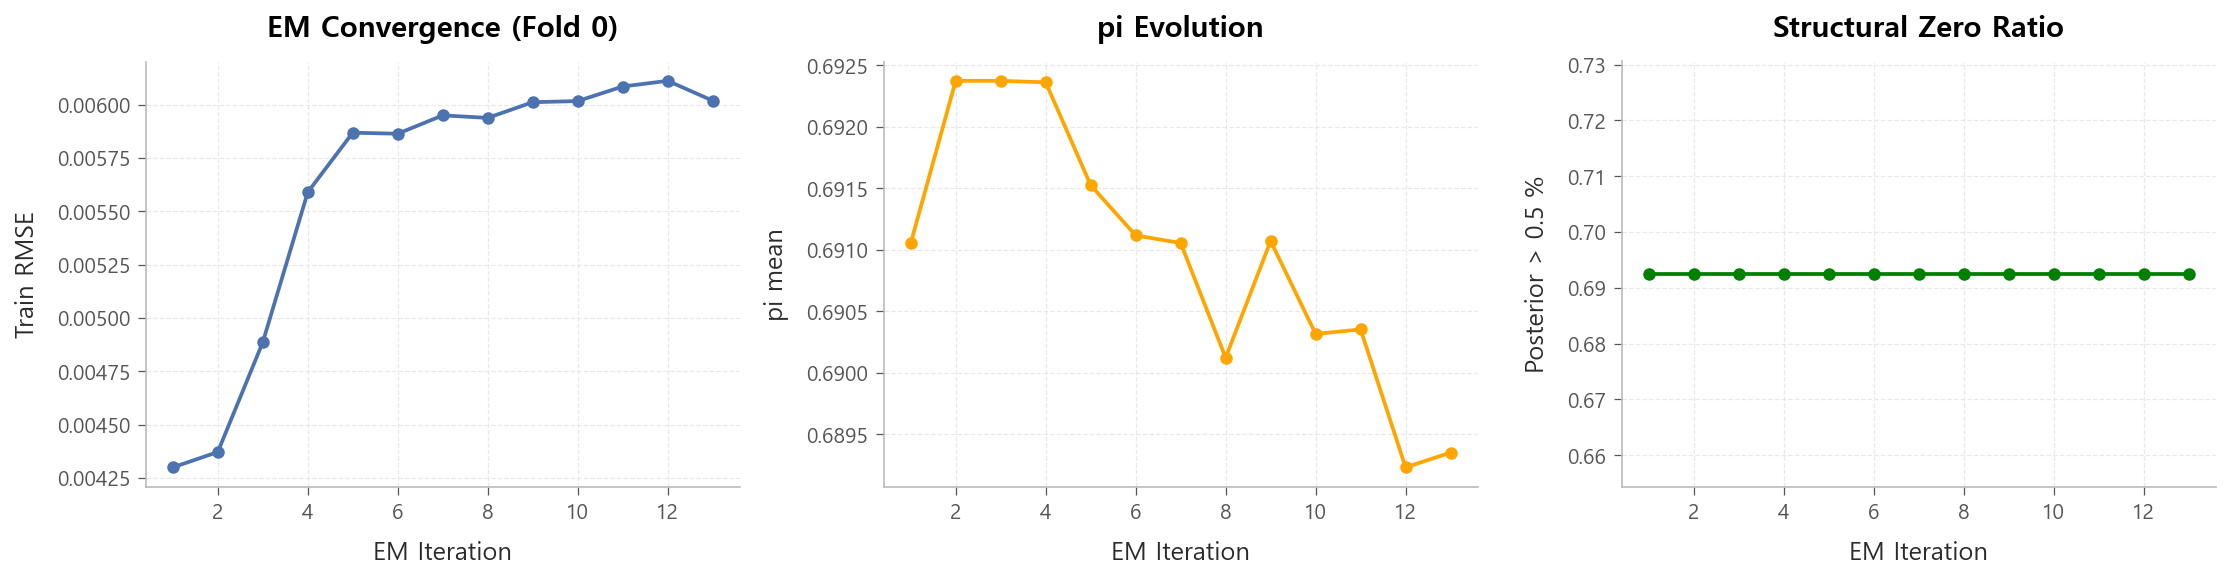


=== Metrics ===
stage    model split metric    value
  reg zitboost train   rmse 0.006760
  reg zitboost   val   rmse 0.005839
  reg zitboost  test   rmse 0.008500


In [8]:
# ── EM Convergence 진단 ──
# ZITboost fold 모델들에서 em_history_ 추출
per_model_reg = final.get('per_model_reg', {})
zit_data = per_model_reg.get('zitboost', {})
fold_models = zit_data.get('fold_models', [])

if fold_models:
    print("=== EM Convergence (fold별) ===")
    for i, model in enumerate(fold_models):
        if hasattr(model, 'em_history_') and model.em_history_:
            last = model.em_history_[-1]
            print(f"  Fold {i}: final RMSE={last['rmse']:.6f}, "
                  f"π_mean={last['pi_mean']:.4f}, "
                  f"posterior_zero%={last['posterior_zero_pct']:.3f}")

    # EM iter별 RMSE 추이 (첫 fold)
    if hasattr(fold_models[0], 'em_history_'):
        em_df = pd.DataFrame(fold_models[0].em_history_)
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        axes[0].plot(em_df['iter'], em_df['rmse'], 'o-')
        axes[0].set_xlabel('EM Iteration')
        axes[0].set_ylabel('Train RMSE')
        axes[0].set_title('EM Convergence (Fold 0)')

        axes[1].plot(em_df['iter'], em_df['pi_mean'], 'o-', color='orange')
        axes[1].set_xlabel('EM Iteration')
        axes[1].set_ylabel('pi mean')
        axes[1].set_title('pi Evolution')

        axes[2].plot(em_df['iter'], em_df['posterior_zero_pct'], 'o-', color='green')
        axes[2].set_xlabel('EM Iteration')
        axes[2].set_ylabel('Posterior > 0.5 %')
        axes[2].set_title('Structural Zero Ratio')

        plt.tight_layout()
        plt.show()

# ── Metrics (rerun 함수가 이미 계산한 per-model RMSE 사용) ──
# per_model_reg의 예측은 die-level이므로 unit_data(unit-level)와 직접 비교 불가.
# rerun_best_trial_with_pp가 die→unit 집계 후 계산한 per_model_val/test_rmse를 사용.
metrics_rows = []
per_model_val_rmse = final.get('per_model_val_rmse', {})
per_model_test_rmse = final.get('per_model_test_rmse', {})

# OOF (train) RMSE
oof_rmse_val = final.get('oof_rmse')
if oof_rmse_val is not None:
    metrics_rows.append({
        'stage': 'reg', 'model': 'zitboost', 'split': 'train',
        'metric': 'rmse', 'value': oof_rmse_val,
    })

# Val RMSE
if 'zitboost' in per_model_val_rmse and per_model_val_rmse['zitboost'] is not None:
    metrics_rows.append({
        'stage': 'reg', 'model': 'zitboost', 'split': 'val',
        'metric': 'rmse', 'value': per_model_val_rmse['zitboost'],
    })

# Test RMSE
if EVAL_TEST and 'zitboost' in per_model_test_rmse and per_model_test_rmse['zitboost'] is not None:
    metrics_rows.append({
        'stage': 'reg', 'model': 'zitboost', 'split': 'test',
        'metric': 'rmse', 'value': per_model_test_rmse['zitboost'],
    })

if metrics_rows:
    metrics_df = pd.DataFrame(metrics_rows)
    if SAVE_OUTPUTS:
        metrics_df.to_csv(os.path.join(OOF_DIR, 'metrics.csv'), index=False)
    print("\n=== Metrics ===")
    print(metrics_df.to_string(index=False))

## 9. 모델 진단: Feature Importance + π 분포

- **Feature Importance**: μ(회귀) / π(zero 분류) / φ(분산) 각각의 Top-20 피처 비교
- **π 분포**: 실제 y=0 vs y>0 그룹별 π(x) 분포 → zero/nonzero 분리 품질 확인

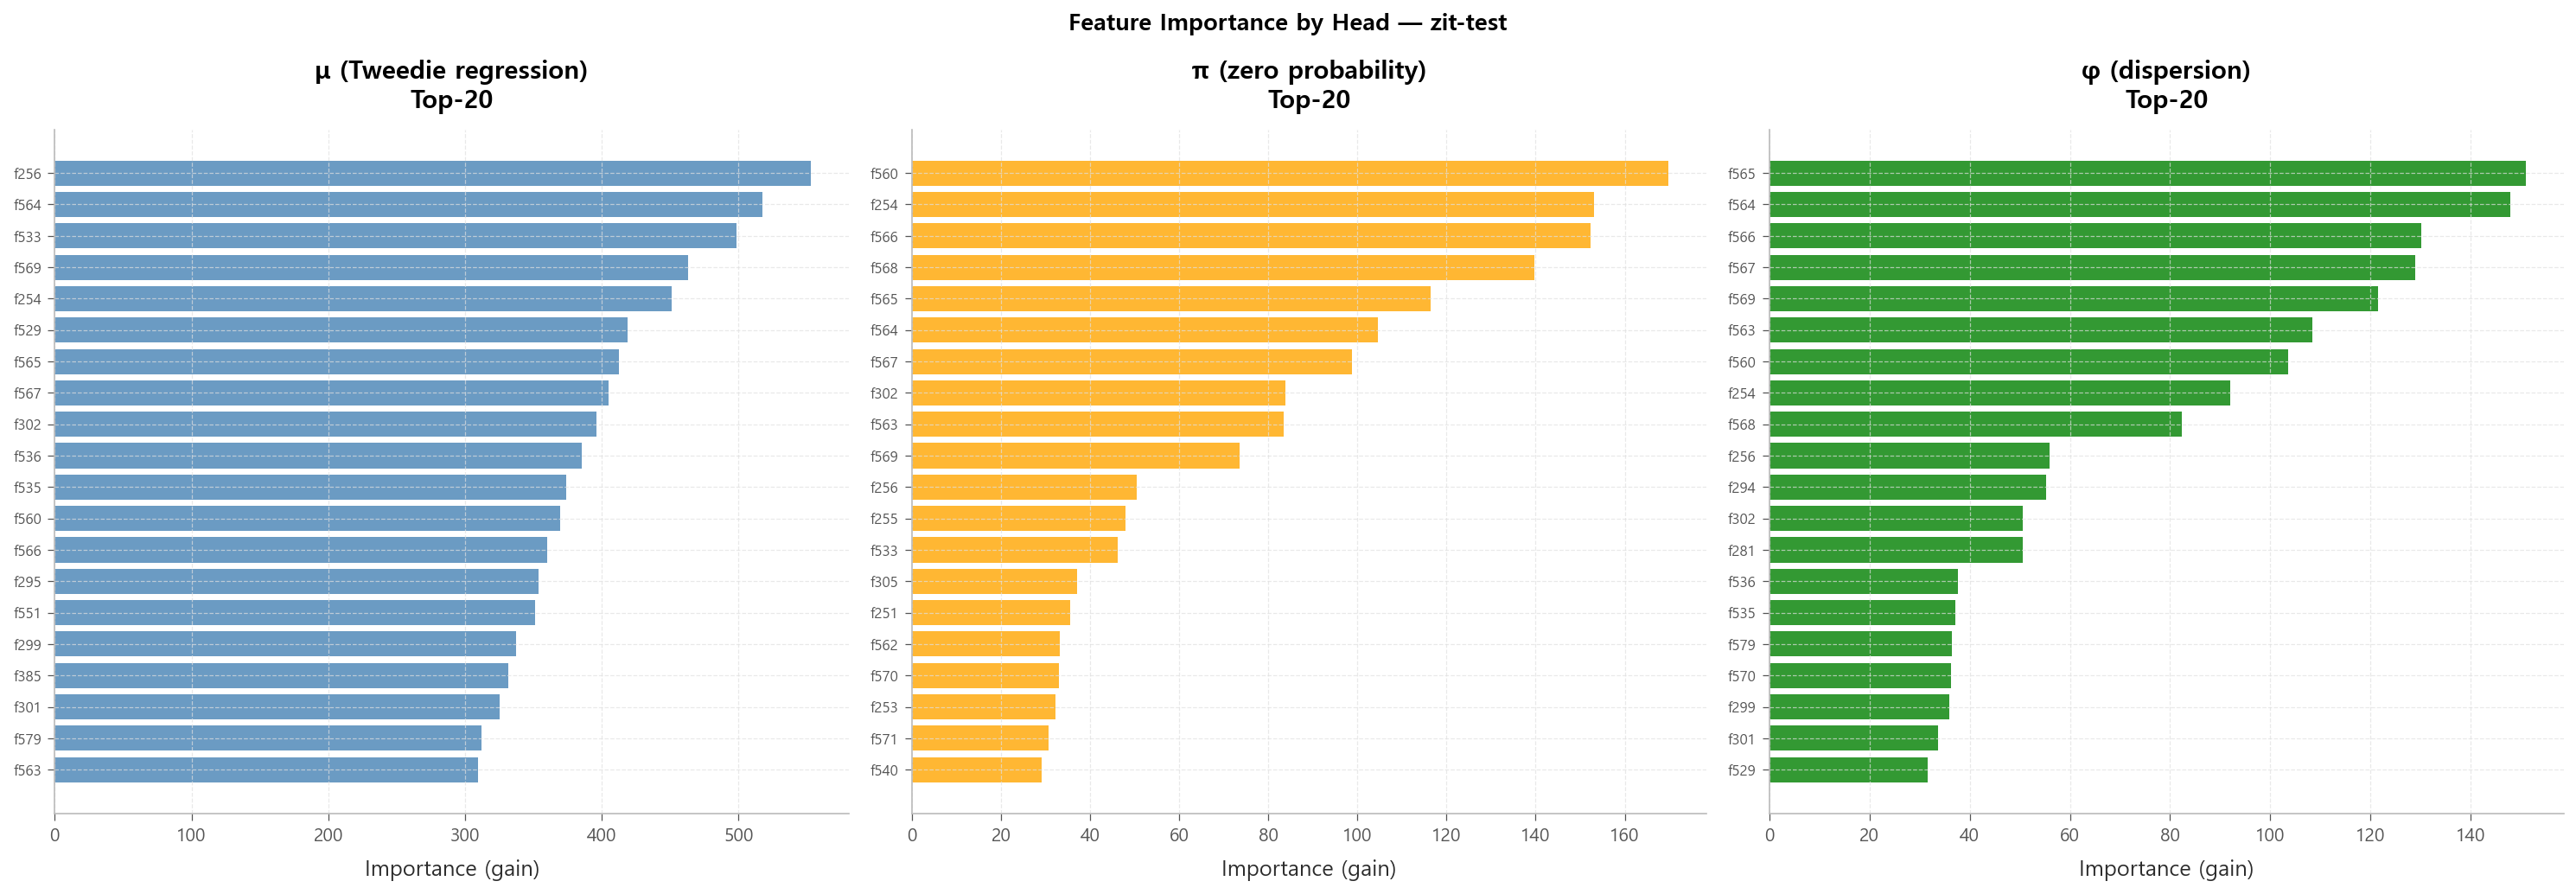


=== μ vs π Top-20 피처 비교 ===
  교집합 (12개): ['f254', 'f256', 'f302', 'f533', 'f535', 'f560', 'f563', 'f564', 'f565', 'f566', 'f567', 'f569']
  μ only (8개): ['f295', 'f299', 'f301', 'f385', 'f529', 'f536', 'f551', 'f579']
  π only (8개): ['f251', 'f253', 'f255', 'f305', 'f562', 'f568', 'f570', 'f571']
피처 불일치: model expects 586, data has 0 → π 분포 스킵


In [9]:
# ── Feature Importance (μ / π / φ) + π 분포 진단 ──

per_model_reg = final.get('per_model_reg', {})
zit_data = per_model_reg.get('zitboost', {})
fold_models = zit_data.get('fold_models', [])

if not fold_models:
    print("fold_models 없음 — 스킵")
else:
    # ── 1) Feature Importance: fold 평균 (gain 기반) ──
    # rerun에서 사용한 피처 이름 추출
    feat_names = zit_data.get('feature_names', None)
    if feat_names is None:
        # fallback: 모델의 n_features로 추정
        n_feat = fold_models[0].lgb_mu_.n_features_
        feat_names = [f'f{i}' for i in range(n_feat)]

    top_k = 20

    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    head_labels = [
        ('lgb_mu_', 'μ (Tweedie regression)', 'steelblue'),
        ('lgb_pi_', 'π (zero probability)', 'orange'),
        ('lgb_phi_', 'φ (dispersion)', 'green'),
    ]

    for ax, (attr, title, color) in zip(axes, head_labels):
        # fold별 importance 수집 → 평균
        imp_sum = np.zeros(len(feat_names))
        n_valid = 0
        for m in fold_models:
            sub_model = getattr(m, attr, None)
            if sub_model is not None:
                imp = sub_model.feature_importances_
                if len(imp) == len(feat_names):
                    imp_sum += imp
                    n_valid += 1

        if n_valid == 0:
            ax.text(0.5, 0.5, 'No importance data', ha='center', va='center')
            ax.set_title(title)
            continue

        imp_avg = imp_sum / n_valid
        imp_df = pd.DataFrame({'feature': feat_names, 'importance': imp_avg})
        imp_df = imp_df.sort_values('importance', ascending=False).head(top_k)

        ax.barh(range(top_k), imp_df['importance'].values[::-1], color=color, alpha=0.8)
        ax.set_yticks(range(top_k))
        ax.set_yticklabels(imp_df['feature'].values[::-1], fontsize=8)
        ax.set_xlabel('Importance (gain)')
        ax.set_title(f'{title}\nTop-{top_k}')

    plt.suptitle(f'Feature Importance by Head — {EXP_ID}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    if SAVE_OUTPUTS:
        plt.savefig(os.path.join(OOF_DIR, 'feature_importance.png'), dpi=150, bbox_inches='tight')
    plt.show()

    # ── μ vs π Top-20 교집합/차집합 ──
    mu_imp = np.zeros(len(feat_names))
    pi_imp = np.zeros(len(feat_names))
    n_mu, n_pi = 0, 0
    for m in fold_models:
        if hasattr(m, 'lgb_mu_'):
            imp = m.lgb_mu_.feature_importances_
            if len(imp) == len(feat_names):
                mu_imp += imp; n_mu += 1
        if hasattr(m, 'lgb_pi_'):
            imp = m.lgb_pi_.feature_importances_
            if len(imp) == len(feat_names):
                pi_imp += imp; n_pi += 1

    if n_mu > 0 and n_pi > 0:
        mu_top = set(pd.Series(mu_imp / n_mu, index=feat_names)
                     .nlargest(top_k).index)
        pi_top = set(pd.Series(pi_imp / n_pi, index=feat_names)
                     .nlargest(top_k).index)
        overlap = mu_top & pi_top
        mu_only = mu_top - pi_top
        pi_only = pi_top - mu_top

        print(f"\n=== μ vs π Top-{top_k} 피처 비교 ===")
        print(f"  교집합 ({len(overlap)}개): {sorted(overlap)}")
        print(f"  μ only ({len(mu_only)}개): {sorted(mu_only)}")
        print(f"  π only ({len(pi_only)}개): {sorted(pi_only)}")

    # ── 2) π 분포 (y=0 vs y>0) ──
    # die-level 데이터에서 π 추출
    ud_die = final.get('unit_data_die', final.get('unit_data', {}))
    train_die = ud_die.get('train')

    if train_die is not None and len(fold_models) > 0:
        # Fold 0 모델로 train 전체의 π 추출 (진단용)
        model0 = fold_models[0]
        # rerun에서 사용한 전처리된 X 추출
        train_pred_key = 'oof_pred'
        oof_pred = zit_data.get(train_pred_key)

        # predict_components로 π 추출 (전처리된 X 필요)
        # → fold_models[0]이 학습한 X와 동일한 피처로 predict해야 함
        # → unit_data_die['train']에서 feat_cols 추출
        feat_in_data = [c for c in feat_names if c in train_die.columns]

        if len(feat_in_data) == len(feat_names):
            X_diag = train_die[feat_names].values
            pi_vals, mu_vals, phi_vals = model0.predict_components(X_diag)
            y_die = train_die[TARGET_COL].values

            fig, axes = plt.subplots(1, 3, figsize=(18, 5))

            # (0) π 분포: y=0 vs y>0
            ax = axes[0]
            ax.hist(pi_vals[y_die == 0], bins=60, alpha=0.7, density=True,
                    label=f'y=0 (n={int((y_die==0).sum())})', color='steelblue',
                    edgecolor='steelblue', linewidth=0.3)
            ax.hist(pi_vals[y_die > 0], bins=60, alpha=0.7, density=True,
                    label=f'y>0 (n={int((y_die>0).sum())})', color='orange',
                    edgecolor='darkorange', linewidth=0.3)
            ax.set_xlabel('π(x) = P(structural zero)')
            ax.set_ylabel('Density')
            ax.set_title('π Distribution: y=0 vs y>0')
            ax.legend()

            # 분리도 지표
            pi_mean_zero = pi_vals[y_die == 0].mean()
            pi_mean_pos = pi_vals[y_die > 0].mean()
            ax.axvline(pi_mean_zero, color='steelblue', linestyle='--', alpha=0.6)
            ax.axvline(pi_mean_pos, color='darkorange', linestyle='--', alpha=0.6)
            ax.text(0.03, 0.95, f'π mean:\n  y=0: {pi_mean_zero:.4f}\n  y>0: {pi_mean_pos:.4f}\n  Δ: {pi_mean_zero-pi_mean_pos:.4f}',
                    transform=ax.transAxes, va='top', fontsize=8,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

            # (1) μ 분포: y=0 vs y>0
            ax = axes[1]
            mu_clip = np.clip(mu_vals, 0, np.percentile(mu_vals, 99))
            ax.hist(mu_clip[y_die == 0], bins=60, alpha=0.7, density=True,
                    label='y=0', color='steelblue', edgecolor='steelblue', linewidth=0.3)
            ax.hist(mu_clip[y_die > 0], bins=60, alpha=0.7, density=True,
                    label='y>0', color='orange', edgecolor='darkorange', linewidth=0.3)
            ax.set_xlabel('μ(x) = Tweedie mean')
            ax.set_ylabel('Density')
            ax.set_title('μ Distribution: y=0 vs y>0')
            ax.legend()

            # (2) 최종 pred = (1-π)×μ 분포
            ax = axes[2]
            final_pred = (1 - pi_vals) * mu_vals
            fp_clip = np.clip(final_pred, 0, np.percentile(final_pred[final_pred > 0], 99) if (final_pred > 0).any() else 0.01)
            ax.hist(fp_clip[y_die == 0], bins=60, alpha=0.7, density=True,
                    label='y=0', color='steelblue', edgecolor='steelblue', linewidth=0.3)
            ax.hist(fp_clip[y_die > 0], bins=60, alpha=0.7, density=True,
                    label='y>0', color='orange', edgecolor='darkorange', linewidth=0.3)
            ax.set_xlabel('(1-π)×μ = final prediction')
            ax.set_ylabel('Density')
            ax.set_title('Final Pred Distribution: y=0 vs y>0')
            ax.legend()

            plt.suptitle(f'ZITboost Component Diagnostics (Fold 0, train) — {EXP_ID}',
                         fontsize=13, fontweight='bold')
            plt.tight_layout()
            if SAVE_OUTPUTS:
                plt.savefig(os.path.join(OOF_DIR, 'component_diagnostics.png'), dpi=150, bbox_inches='tight')
            plt.show()

            # 수치 요약
            print(f"\n=== ZITboost Component 요약 (Fold 0, train die-level) ===")
            print(f"  π: mean={pi_vals.mean():.4f}, std={pi_vals.std():.4f}")
            print(f"     y=0 mean={pi_mean_zero:.4f}, y>0 mean={pi_mean_pos:.4f}, Δ={pi_mean_zero-pi_mean_pos:.4f}")
            print(f"  μ: mean={mu_vals.mean():.6f}, std={mu_vals.std():.6f}")
            print(f"  φ: mean={phi_vals.mean():.4f}, std={phi_vals.std():.4f}")
            print(f"  (1-π)×μ: mean={final_pred.mean():.6f}, zero%={(final_pred < 1e-6).mean()*100:.1f}%")
        else:
            print(f"피처 불일치: model expects {len(feat_names)}, data has {len(feat_in_data)} → π 분포 스킵")

## 10. 집계 함수 탐색 + Position 가중치

die-level OOF 예측을 unit-level로 집계하는 최적 방법 탐색.  
- mean / weighted(SLSQP) / max / min / median / trimmed_mean 비교
- weighted: position별 가중치 (w1~w4) SLSQP 최적화

In [10]:
from scipy.optimize import minimize

# ── Helper: die-level OOF → unit-level ──
def _get_die_data(split_name):
    """final dict에서 die-level 데이터 추출."""
    ud_die = final.get('unit_data_die')
    if ud_die is not None and split_name in ud_die:
        return ud_die[split_name]
    return final['unit_data'][split_name]

def _unit_y_true(split_name, ufs_order):
    """unit-level y_true."""
    d = _get_die_data(split_name)
    return (d.groupby(KEY_COL, sort=False)[TARGET_COL]
            .first()
            .reindex(ufs_order)
            .values)

def _get_pred_pivot(split_name):
    """die-level 예측 → (n_units, 4) pivot table."""
    d = _get_die_data(split_name)
    pred_key = 'oof_pred' if split_name == 'train' else f'{split_name}_pred'
    pred = per_model_reg['zitboost'][pred_key]

    df = pd.DataFrame({
        KEY_COL: d[KEY_COL].values,
        POSITION_COL: d[POSITION_COL].values if POSITION_COL in d.columns else 1,
        'pred': pred,
    })
    pivot = df.pivot_table(
        index=KEY_COL, columns=POSITION_COL,
        values='pred', aggfunc='mean'
    ).reindex(columns=[1, 2, 3, 4])
    return pivot

# ── Position Weight 최적화 (SLSQP) ──
def find_best_pos_weights(pred_pivot, y_true, bounds=(0.15, 0.35)):
    """(n_units, 4) @ (4,) → (n_units,) 최적 가중치."""
    def obj(w):
        w_norm = w / w.sum()
        return np.sqrt(np.mean((y_true - pred_pivot @ w_norm) ** 2))

    res = minimize(
        obj, x0=[0.25] * 4, method='SLSQP',
        bounds=[bounds] * 4,
        constraints={'type': 'eq', 'fun': lambda w: w.sum() - 1.0},
    )
    return res.x / res.x.sum(), res.fun

# ── 집계 함수 탐색 ──
pivot_val = _get_pred_pivot('val')
ufs_val = pivot_val.index.values
y_val = _unit_y_true('val', ufs_val)

agg_results = {}

# 1) mean
pred_mean = pivot_val.values.mean(axis=1)
agg_results['mean'] = rmse(y_val, pred_mean)

# 2) weighted (SLSQP)
bounds = postprocess_config['position_weight_range']
best_w_pos, rmse_weighted = find_best_pos_weights(pivot_val.values, y_val, bounds)
agg_results['weighted'] = rmse_weighted

# 3) max
agg_results['max'] = rmse(y_val, pivot_val.values.max(axis=1))

# 4) min
agg_results['min'] = rmse(y_val, pivot_val.values.min(axis=1))

# 5) median
agg_results['median'] = rmse(y_val, np.median(pivot_val.values, axis=1))

# 6) trimmed_mean (최대/최소 제거, 중간 2개 평균)
sorted_vals = np.sort(pivot_val.values, axis=1)
agg_results['trimmed_mean'] = rmse(y_val, sorted_vals[:, 1:3].mean(axis=1))

# ── 결과 출력 ──
print("=== 집계 함수별 Val RMSE ===")
agg_df = pd.DataFrame([
    {'method': k, 'val_rmse': v} for k, v in agg_results.items()
]).sort_values('val_rmse')
print(agg_df.to_string(index=False))

# Best 선택
if postprocess_config['agg_method'] == 'auto':
    best_agg = agg_df.iloc[0]['method']
else:
    best_agg = postprocess_config['agg_method']

print(f"\n→ Best aggregation: {best_agg} (RMSE={agg_results[best_agg]:.6f})")
if best_agg == 'weighted':
    print(f"  Position weights: {best_w_pos}")

if SAVE_OUTPUTS:
    agg_df.to_csv(os.path.join(OOF_DIR, 'agg_comparison.csv'), index=False)

=== 집계 함수별 Val RMSE ===
      method  val_rmse
         max  0.005830
        mean  0.005839
    weighted  0.005839
      median  0.005840
trimmed_mean  0.005840
         min  0.005859

→ Best aggregation: max (RMSE=0.005830)


## 11. π Threshold Tuning

ZITboost predict = (1-π)×μ.  
π가 높으면 예측값이 작아지므로, 예측값의 하위 분위수를 0으로 강제하여 zero-inflation을 반영.  
Quantile 기반 grid search로 최적 threshold 탐색.

In [11]:
# ── π threshold tuning (ZITboost 전용) ──
# predict_components로 π 추출 → π > threshold이면 pred=0

def _apply_best_agg(pivot, method, w_pos=None):
    """선택된 집계 함수 적용."""
    vals = pivot.values
    if method == 'mean':
        return vals.mean(axis=1)
    elif method == 'weighted':
        return vals @ (w_pos / w_pos.sum())
    elif method == 'max':
        return vals.max(axis=1)
    elif method == 'min':
        return vals.min(axis=1)
    elif method == 'median':
        return np.median(vals, axis=1)
    elif method == 'trimmed_mean':
        s = np.sort(vals, axis=1)
        return s[:, 1:3].mean(axis=1)
    else:
        return vals.mean(axis=1)

# 집계된 unit-level 예측
unit_pred_val = _apply_best_agg(pivot_val, best_agg, best_w_pos)

# π threshold: 예측값 기반 (ZITboost predict = (1-π)×μ 이므로,
# π가 높으면 예측값이 작아짐 → 예측값 < threshold를 zero로)
pi_cfg = postprocess_config
if pi_cfg['pi_threshold'] is not None:
    if pi_cfg['pi_threshold'] == 'auto':
        pi_lo, pi_hi = pi_cfg['pi_threshold_range']
        pi_step = pi_cfg['pi_threshold_step']

        # "예측값의 몇 분위수 이하를 0으로" 하는 방식
        pi_results = []
        for q in np.arange(pi_lo, pi_hi, pi_step):
            thr = np.quantile(unit_pred_val, q)
            clipped = np.where(unit_pred_val < thr, 0.0, unit_pred_val)
            pi_results.append({'quantile': q, 'threshold': thr,
                               'val_rmse': rmse(y_val, clipped),
                               'n_zeroed': (clipped == 0).sum()})

        pi_df = pd.DataFrame(pi_results).sort_values('val_rmse')
        best_pi_q = pi_df.iloc[0]['quantile']
        best_pi_thr = pi_df.iloc[0]['threshold']

        print("=== π Threshold (Quantile-based Zero Forcing) ===")
        print(pi_df.head(10).to_string(index=False))
        print(f"\n→ Best quantile: {best_pi_q:.2f} (threshold={best_pi_thr:.6f}, "
              f"RMSE={pi_df.iloc[0]['val_rmse']:.6f})")

        # 적용
        unit_pred_val = np.where(unit_pred_val < best_pi_thr, 0.0, unit_pred_val)
    else:
        # 고정 threshold
        best_pi_thr = float(pi_cfg['pi_threshold'])
        unit_pred_val = np.where(unit_pred_val < best_pi_thr, 0.0, unit_pred_val)
        best_pi_q = None
else:
    best_pi_thr = None
    best_pi_q = None
    print("π threshold: disabled")

print(f"\nAfter π threshold: Val RMSE = {rmse(y_val, unit_pred_val):.6f}")

=== π Threshold (Quantile-based Zero Forcing) ===
 quantile  threshold  val_rmse  n_zeroed
     0.02   0.000885  0.005830       175
     0.03   0.000955  0.005830       262
     0.01   0.000767  0.005830        88
     0.00   0.000438  0.005830         0
     0.04   0.001023  0.005831       350
     0.05   0.001080  0.005832       437
     0.06   0.001125  0.005833       524
     0.07   0.001177  0.005835       611
     0.08   0.001219  0.005837       699
     0.09   0.001268  0.005838       786

→ Best quantile: 0.02 (threshold=0.000885, RMSE=0.005830)

After π threshold: Val RMSE = 0.005830


## 12. Zero Clip + 최종 예측 + CSV 저장

- Zero clip: **train OOF** 기반 grid search로 최적 threshold 탐색 (0→0.002, step=0.0005)
- 찾은 threshold를 val/test에 그대로 적용
- 최종 예측: π threshold + zero_clip + clip(0, None)
- Val/Test 예측 CSV + combined_best.json 저장

In [12]:
# ── Zero Clip (train OOF 기반 grid search) ──
# train OOF 예측으로 최적 threshold를 찾고, val/test에 적용

# train OOF 준비
pivot_train = _get_pred_pivot('train')
ufs_train = pivot_train.index.values
y_train = _unit_y_true('train', ufs_train)
unit_pred_train_raw = _apply_best_agg(pivot_train, best_agg, best_w_pos)

# π threshold를 train에도 동일 적용
if best_pi_thr is not None and best_pi_thr > 0:
    unit_pred_train = np.where(unit_pred_train_raw < best_pi_thr, 0.0, unit_pred_train_raw)
else:
    unit_pred_train = unit_pred_train_raw.copy()

zc_cfg = postprocess_config
if zc_cfg['zero_clip_threshold'] is not None:
    if zc_cfg['zero_clip_threshold'] == 'auto':
        lo, hi = zc_cfg['zero_clip_range']
        step = zc_cfg['zero_clip_step']
        thresholds = np.arange(lo, hi + step/2, step)

        # ★ Train OOF 기반 grid search
        zc_results = []
        for thr in thresholds:
            clipped = np.where(unit_pred_train < thr, 0.0, unit_pred_train)
            clipped = np.clip(clipped, 0.0, None)
            zc_results.append({
                'threshold': round(thr, 4),
                'train_oof_rmse': rmse(y_train, clipped),
                'n_zeroed': int((clipped == 0).sum()),
                'zero_pct': (clipped == 0).mean() * 100,
            })

        zc_df = pd.DataFrame(zc_results).sort_values('train_oof_rmse')
        best_zc_thr = zc_df.iloc[0]['threshold']

        print("=== Zero Clip Threshold (Train OOF 기반) ===")
        print(zc_df.to_string(index=False))
        print(f"\n→ Best zero_clip: {best_zc_thr:.4f} "
              f"(Train OOF RMSE={zc_df.iloc[0]['train_oof_rmse']:.6f})")
    else:
        best_zc_thr = float(zc_cfg['zero_clip_threshold'])
else:
    best_zc_thr = 0.0

# ── 최종 예측 적용 함수 ──
def apply_postprocess(pred_raw, pi_thr, zc_thr):
    """π threshold + zero_clip 적용."""
    pred = pred_raw.copy()
    if pi_thr is not None and pi_thr > 0:
        pred = np.where(pred < pi_thr, 0.0, pred)
    if zc_thr > 0:
        pred = np.where(pred < zc_thr, 0.0, pred)
    return np.clip(pred, 0.0, None)

# ── Val 최종 ──
final_val_pred = apply_postprocess(
    _apply_best_agg(pivot_val, best_agg, best_w_pos),
    best_pi_thr, best_zc_thr
)
val_rmse_final = rmse(y_val, final_val_pred)
print(f"\n[Val] Final RMSE = {val_rmse_final:.6f}")

# ── Test 최종 ──
test_rmse_final = None
if EVAL_TEST:
    pivot_test = _get_pred_pivot('test')
    ufs_test = pivot_test.index.values
    y_test = _unit_y_true('test', ufs_test)

    final_test_pred = apply_postprocess(
        _apply_best_agg(pivot_test, best_agg, best_w_pos),
        best_pi_thr, best_zc_thr
    )
    test_rmse_final = rmse(y_test, final_test_pred)
    print(f"[Test] Final RMSE = {test_rmse_final:.6f}")

# ── Train 최종 (참고용) ──
final_train_pred = apply_postprocess(unit_pred_train_raw, best_pi_thr, best_zc_thr)
train_rmse_final = rmse(y_train, final_train_pred)
print(f"[Train OOF] Final RMSE = {train_rmse_final:.6f}")

# ── CSV 저장 ──
if SAVE_OUTPUTS:
    # Val
    val_out = pd.DataFrame({
        KEY_COL: ufs_val,
        TARGET_COL: y_val,
        'final_pred': final_val_pred,
    })
    val_out.to_csv(os.path.join(OOF_DIR, 'final_pred_val.csv'), index=False)

    # Test
    if EVAL_TEST:
        test_out = pd.DataFrame({
            KEY_COL: ufs_test,
            TARGET_COL: y_test,
            'final_pred': final_test_pred,
        })
        test_out.to_csv(os.path.join(OOF_DIR, 'final_pred_test.csv'), index=False)

    # Train OOF
    train_out = pd.DataFrame({
        KEY_COL: ufs_train,
        TARGET_COL: y_train,
        'final_pred': final_train_pred,
    })
    train_out.to_csv(os.path.join(OOF_DIR, 'final_pred_train_oof.csv'), index=False)

    # combined_best.json (재현 정보 포함)
    combined_best = {
        'exp_id': EXP_ID,
        'exp_memo': EXP_MEMO,
        'user': USER,
        'device': DEVICE,
        # ── Optuna best ──
        'best_params': {k: (v.item() if hasattr(v, 'item') else v)
                        for k, v in best_params.items()},
        'best_optuna_rmse': best_value,
        # ── 후처리 결과 ──
        'best_agg_method': best_agg,
        'position_weights': best_w_pos.tolist() if best_agg == 'weighted' else None,
        'pi_threshold': float(best_pi_thr) if best_pi_thr is not None else None,
        'pi_quantile': float(best_pi_q) if best_pi_q is not None else None,
        'zero_clip_threshold': float(best_zc_thr),
        # ── RMSE ──
        'train_oof_rmse': train_rmse_final,
        'val_rmse': val_rmse_final,
        'test_rmse': test_rmse_final,
        # ── 재현 정보 ──
        'pipeline_config': pipeline_config,
        'e2e_params': e2e_params,
        'rerun_params': rerun_params,
        'sampling_params': sampling_params,
        'target_transform': TARGET_TRANSFORM,
        'clip_y_extreme': CLIP_Y_EXTREME,
        'exclude_cols': EXCLUDE_COLS,
        'preprocessing_search_space': {
            'PP_CLEAN_CANDIDATES':   {k: list(v) for k, v in PP_CLEAN_CANDIDATES.items()},
            'PP_OUTLIER_CANDIDATES': {k: list(v) for k, v in PP_OUTLIER_CANDIDATES.items()},
            'AGG_PRESETS':           [list(p) for p in AGG_PRESETS],
        },
    }
    with open(os.path.join(OOF_DIR, 'combined_best.json'), 'w') as f:
        json.dump(combined_best, f, indent=2, ensure_ascii=False)

    # ── Best fold_models pkl 저장 ──
    import pickle
    pkl_path = os.path.join(OOF_DIR, 'best_fold_models.pkl')
    pkl_data = {
        'fold_models': fold_models,
        'feature_names': zit_data.get('feature_names'),
        'n_folds': len(fold_models),
        'exp_id': EXP_ID,
        'best_params': best_params,
    }
    with open(pkl_path, 'wb') as f:
        pickle.dump(pkl_data, f)
    pkl_mb = os.path.getsize(pkl_path) / 1024 / 1024
    print(f"Saved: {pkl_path} ({pkl_mb:.1f} MB, {len(fold_models)} folds)")

    print(f"\nSaved to {OOF_DIR}")

=== Zero Clip Threshold (Train OOF 기반) ===
 threshold  train_oof_rmse  n_zeroed  zero_pct
    0.0000        0.006743        61  4.660046
    0.0005        0.006743        61  4.660046
    0.0010        0.006745        90  6.875477
    0.0015        0.006779       272 20.779221
    0.0020        0.006885       559 42.704354

→ Best zero_clip: 0.0000 (Train OOF RMSE=0.006743)

[Val] Final RMSE = 0.005830
[Test] Final RMSE = 0.008487
[Train OOF] Final RMSE = 0.006743
Saved: c:\Users\Dell5371\Desktop\기업연계프로젝트\4_output\oof\zit-test\best_fold_models.pkl (36.7 MB, 5 folds)

Saved to c:\Users\Dell5371\Desktop\기업연계프로젝트\4_output\oof\zit-test


## 13. Two-Stage 비교 + 시각화

- Two-Stage OOF 파일이 있으면 Val RMSE 비교
- 6패널 시각화: EM Convergence / 집계 비교 / Position Weights / Residual / y_true vs y_pred / Distribution

=== ZITboost vs Two-Stage 비교 ===
ZITboost Val RMSE: 0.005830
Two-Stage OOF 파일 미발견 — 비교 생략


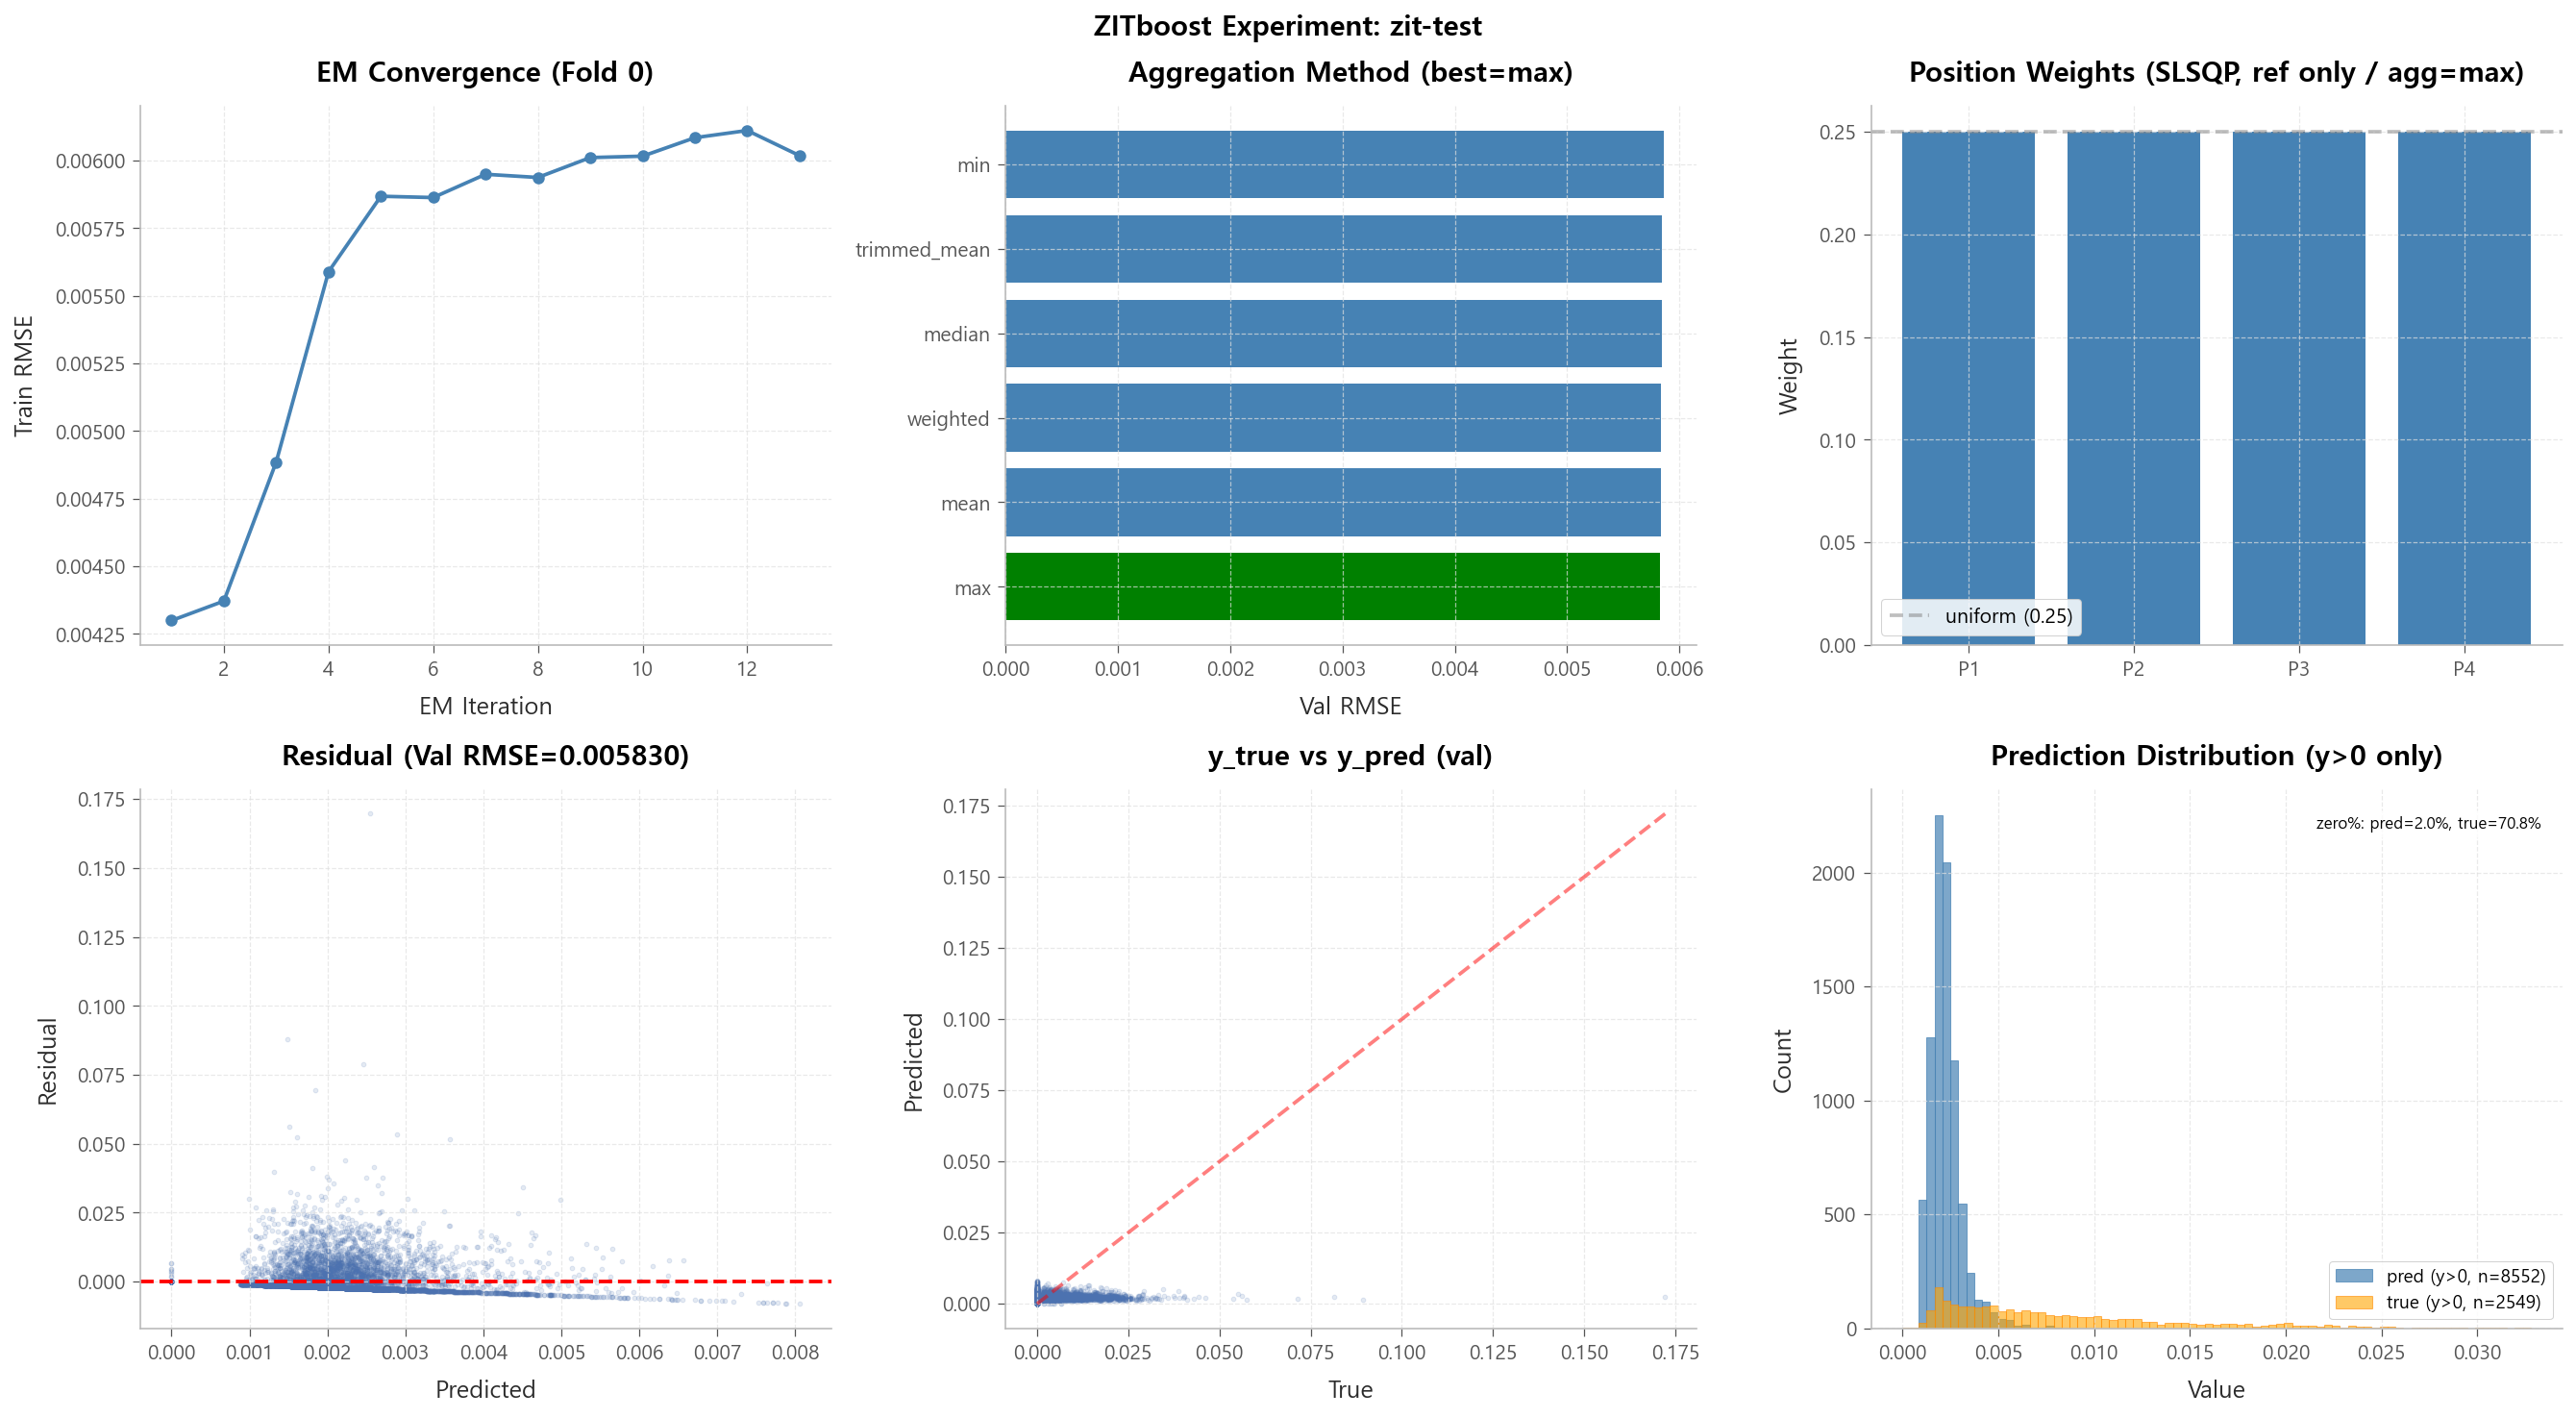

In [13]:
# ── Two-Stage OOF 비교 (있으면 로드) ──
two_stage_dir = os.path.join(OUTPUT_DIR, 'oof')  # Two-Stage OOF 경로
ts_val_path = None

# Two-Stage 결과 탐색
if os.path.exists(two_stage_dir):
    for d in sorted(os.listdir(two_stage_dir)):
        candidate = os.path.join(two_stage_dir, d, 'final_pred_val.csv')
        if os.path.exists(candidate) and d != EXP_ID:
            ts_val_path = candidate
            break

print("=== ZITboost vs Two-Stage 비교 ===")
print(f"ZITboost Val RMSE: {val_rmse_final:.6f}")
if ts_val_path:
    ts_df = pd.read_csv(ts_val_path)
    ts_rmse = rmse(ts_df[TARGET_COL].values, ts_df['final_pred'].values)
    print(f"Two-Stage Val RMSE: {ts_rmse:.6f} (from {ts_val_path})")
    delta = val_rmse_final - ts_rmse
    print(f"Delta RMSE: {delta:+.6f} ({'ZITboost 우세' if delta < 0 else 'Two-Stage 우세'})")
else:
    print("Two-Stage OOF 파일 미발견 — 비교 생략")

# ── 3x2 시각화 ──
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# (0,0) EM Convergence (Fold 0)
ax = axes[0, 0]
if fold_models and hasattr(fold_models[0], 'em_history_'):
    em_df = pd.DataFrame(fold_models[0].em_history_)
    ax.plot(em_df['iter'], em_df['rmse'], 'o-', color='steelblue')
    ax.set_xlabel('EM Iteration')
    ax.set_ylabel('Train RMSE')
    ax.set_title('EM Convergence (Fold 0)')
else:
    ax.text(0.5, 0.5, 'No EM history', ha='center', va='center')

# (0,1) 집계 함수 비교 bar
ax = axes[0, 1]
agg_sorted = agg_df.sort_values('val_rmse')
colors = ['green' if m == best_agg else 'steelblue' for m in agg_sorted['method']]
ax.barh(agg_sorted['method'], agg_sorted['val_rmse'], color=colors)
ax.set_xlabel('Val RMSE')
ax.set_title(f'Aggregation Method (best={best_agg})')

# (0,2) Position weights — 항상 표시 (weighted가 아니어도 참고용)
ax = axes[0, 2]
ax.bar(['P1', 'P2', 'P3', 'P4'], best_w_pos, color='green' if best_agg == 'weighted' else 'steelblue')
ax.axhline(0.25, color='gray', linestyle='--', alpha=0.5, label='uniform (0.25)')
ax.set_ylabel('Weight')
ax.legend()
if best_agg == 'weighted':
    ax.set_title('Position Weights (SLSQP) ★ selected')
else:
    ax.set_title(f'Position Weights (SLSQP, ref only / agg={best_agg})')

# (1,0) Residual plot
ax = axes[1, 0]
residual = y_val - final_val_pred
ax.scatter(final_val_pred, residual, alpha=0.15, s=5)
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel('Predicted')
ax.set_ylabel('Residual')
ax.set_title(f'Residual (Val RMSE={val_rmse_final:.6f})')

# (1,1) y_true vs y_pred
ax = axes[1, 1]
ax.scatter(y_val, final_val_pred, alpha=0.15, s=5)
y_max = max(y_val.max(), final_val_pred.max())
ax.plot([0, y_max], [0, y_max], 'r--', alpha=0.5)
ax.set_xlabel('True')
ax.set_ylabel('Predicted')
ax.set_title('y_true vs y_pred (val)')

# (1,2) Prediction distribution — 겹치는 영역 잘 보이도록 개선
ax = axes[1, 2]
pred_pos = final_val_pred[final_val_pred > 0]
true_pos = y_val[y_val > 0]
bin_max = max(np.percentile(pred_pos, 99) if len(pred_pos) > 0 else 0.01,
              np.percentile(true_pos, 99) if len(true_pos) > 0 else 0.01)
bins = np.linspace(0, bin_max, 80)

ax.hist(pred_pos, bins=bins, alpha=0.7, label=f'pred (y>0, n={len(pred_pos)})',
        color='steelblue', edgecolor='steelblue', linewidth=0.5)
ax.hist(true_pos, bins=bins, alpha=0.6, label=f'true (y>0, n={len(true_pos)})',
        color='orange', edgecolor='darkorange', linewidth=0.5)
ax.set_xlabel('Value')
ax.set_ylabel('Count')
ax.legend(fontsize=9)
ax.set_title('Prediction Distribution (y>0 only)')

# zero 비율 텍스트 표시
pred_zero_pct = (final_val_pred == 0).mean() * 100
true_zero_pct = (y_val == 0).mean() * 100
ax.text(0.97, 0.95, f'zero%: pred={pred_zero_pct:.1f}%, true={true_zero_pct:.1f}%',
        transform=ax.transAxes, ha='right', va='top', fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.suptitle(f'ZITboost Experiment: {EXP_ID}', fontsize=14, fontweight='bold')
plt.tight_layout()

if SAVE_OUTPUTS:
    plt.savefig(os.path.join(OOF_DIR, 'visualization.png'), dpi=150, bbox_inches='tight')
plt.show()